<a href="https://colab.research.google.com/github/juandiegojurcar13/Entrega-PAS-Procesos-Estocasticos/blob/main/GPs_Entrega_PRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega GP's
### Juan Diego Jurado Carrasco


In [1]:
# Importamos librerías básicas que utilizaremos
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se obtienen 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$. Dicho vector sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utilizaremos la función `np.random.multivariate_normal`.

In [2]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.identity(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 1.20034000e-01 -9.96821837e-01  1.54607421e+00]
 [-4.32220081e-01  8.59449822e-01 -2.55588158e-01]
 [ 3.99314289e-01 -2.90032896e-01  2.76864171e-02]
 [ 1.45586286e+00  3.46187568e-01 -5.04383200e-01]
 [ 1.02633928e+00  1.22189019e+00 -6.71302158e-01]
 [ 8.43815390e-02 -6.92855927e-01 -7.49773177e-01]
 [ 9.41928711e-01  2.57736370e+00  2.95008180e-01]
 [ 2.87747170e-01 -2.69953661e-01  5.63706123e-02]
 [-6.87576581e-01 -3.22413872e-01 -2.30660391e-01]
 [-2.55186623e-01 -5.82483577e-01 -7.87753457e-01]
 [-1.28879291e+00  7.31728038e-01  1.99661810e+00]
 [ 2.29115123e+00  4.23530697e-01  5.01479981e-01]
 [ 6.99201072e-01 -3.37042326e-02  1.03067237e+00]
 [-1.76775452e+00  6.68296793e-01  2.16378961e+00]
 [-1.01480908e+00 -1.16779474e+00  2.27197955e+00]
 [ 3.72249721e-02 -2.25917507e+00  1.11540456e+00]
 [ 6.12189423e-01 -4.77130652e-01 -1.00120215e+00]
 [-5.37657555e-01  1.01549752e+00  1.43285103e+00]
 [ 6.76702271e-01  5.72052905e-01 -8.70366487e-01]
 [ 4

Hacemos lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [3]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag(np.array([1, 10, 100]))
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[  0.59843114   1.37361207 -14.55549926]
 [ -1.29460388  -0.82654691 -22.73424576]
 [  0.71428395  -0.2328747    3.68404256]
 [  0.08499407  -0.89343161 -18.93271767]
 [  0.49294274   0.34259365  -1.81897519]
 [  1.07953267   4.20391538  -2.46290241]
 [  0.60786878  -2.59959886  16.3626256 ]
 [  0.42472938   0.48829047   9.86827178]
 [ -0.87680085  -1.18346532  -8.24269444]
 [ -1.31060019  -5.49757012   7.46216456]
 [  1.41067692  -3.1533701    7.78321159]
 [ -0.18064092  -4.25803464   2.6773621 ]
 [  0.44513641   5.82787078   4.2532692 ]
 [  0.73940867  -2.66852852   2.97462972]
 [ -0.26087849  -3.14315951  -1.88342923]
 [  0.34603684   3.2329608   15.16094569]
 [ -1.51980265   1.91615267   3.34251145]
 [  1.17877426  -2.07810064   8.38839567]
 [  0.89102747  -0.3187961   -8.91978183]
 [  1.87170771  -2.65324225  -4.37845928]
 [ -0.26156117   1.39457935   3.13412813]
 [ -0.27429724   1.77775174   5.62362735]
 [ -0.50894002  -3.29854061 -14.04605779]
 [ -1.4

Al haber cambiado la matriz de covarianzas, los datos ahora son más heterogéneros. Varían más entre sí, mientras que con la otra matriz casi todos los datos estaban en torno al $0$, por valores mayores y menores, pero muy cercanos al cero.

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función).

Definimos la función principal:

Los parámetros de la función a definir son los siguientes:
  - t: Vector de localizaciones en los que se quiere simular el GP.
  - sigma_sq: Varianza del kernel.
  - lengthscale: Parámetro de escala del kernel.
  - num_samples: Número de muestras a generar.

La función nos devolverá las muestras del GP.


In [4]:
def simular_GP_RBF(t, sigma_sq, lengthscale, num_samples):
  # Calcular el vector de medias.
  vector_medias = np.zeros_like(t)

  # Calcular la matriz de covarianzas.
  t_fila=t.reshape(1, t.shape[0])
  t_col=t.reshape(t.shape[0], 1)
  matriz_distancias = t_fila-t_col
  matriz_covs = sigma_sq * np.exp(-0.5 * (matriz_distancias / lengthscale)**2)

  # Obtener las simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

## Diapositiva 59


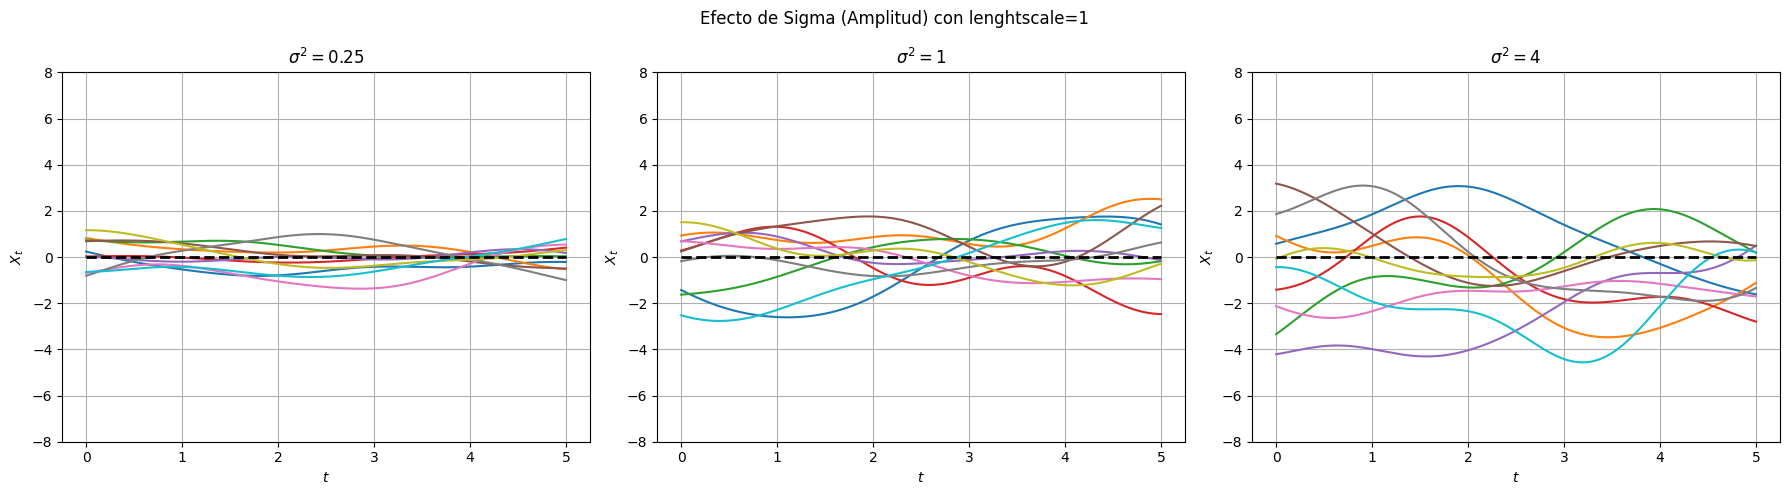

In [5]:
t = np.linspace(0, 5, 400)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Efecto de Sigma (Amplitud) con lenghtscale=1')

# Primer subplot (sigma_sq=0.25)
axes[0].plot(t, simular_GP_RBF(t, 0.25, 1, 10).T)
axes[0].plot(t, np.zeros_like(t), color='black', linestyle='--', linewidth=2)
axes[0].set_title('$\\sigma^2=0.25$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-8, 8)
axes[0].grid()

# Segundo subplot (sigma_sq=1)
axes[1].plot(t, simular_GP_RBF(t, 1, 1, 10).T)
axes[1].plot(t, np.zeros_like(t), color='black', linestyle='--', linewidth=2)
axes[1].set_title('$\\sigma^2=1$')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-8, 8)
axes[1].grid()

# Tercer subplot (sigma_sq=4)
axes[2].plot(t, simular_GP_RBF(t, 4, 1, 10).T)
axes[2].plot(t, np.zeros_like(t), color='black', linestyle='--', linewidth=2)
axes[2].set_title('$\\sigma^2=4$')
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$X_t$')
axes[2].set_ylim(-8, 8)
axes[2].grid()

plt.tight_layout()
plt.show()

## Diapositiva 62

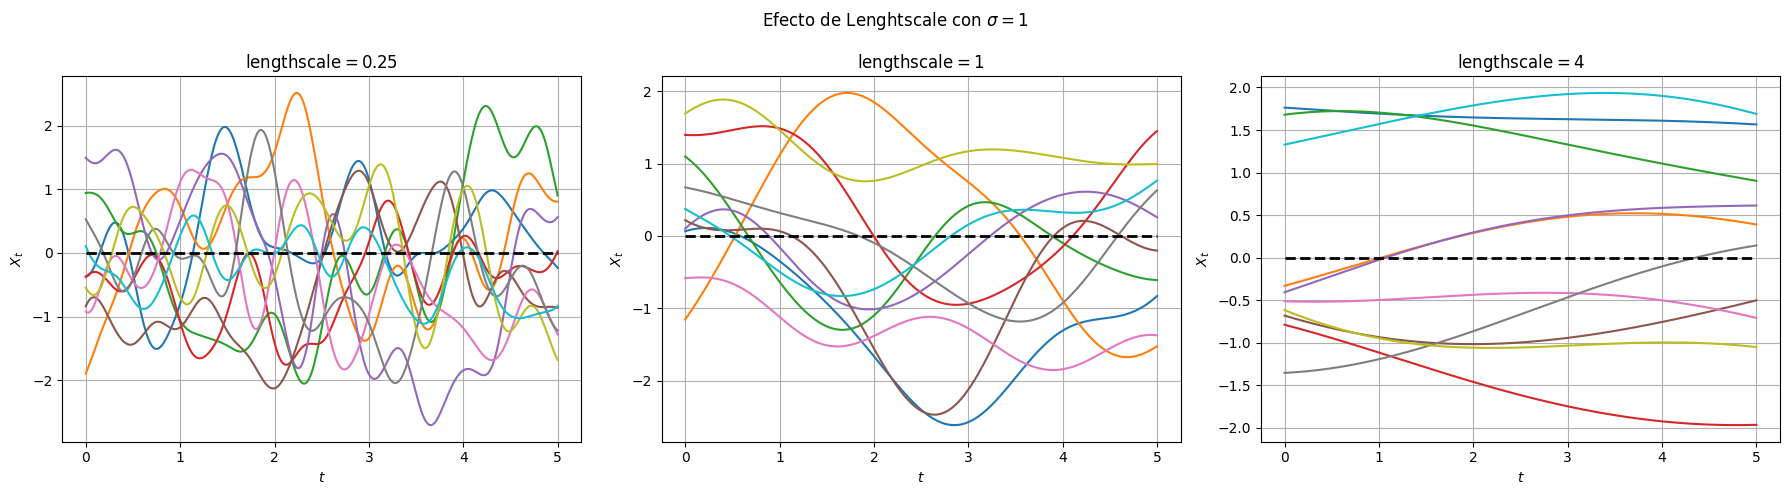

In [6]:
t = np.linspace(0, 5, 400)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Efecto de Lenghtscale con $\\sigma=1$')
axes[0].autoscale(enable=True, axis='both')


# Primer subplot (lengtscale=0.25)
axes[0].plot(t, simular_GP_RBF(t, 1, 0.25, 10).T)
axes[0].plot(t, np.zeros_like(t), color='black', linestyle='--', linewidth=2)
axes[0].set_title('$\\text{lengthscale}=0.25$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].grid()

# Segundo subplot (lengtscale=1)
axes[1].plot(t, simular_GP_RBF(t, 1, 1, 10).T)
axes[1].plot(t, np.zeros_like(t), color='black', linestyle='--', linewidth=2)
axes[1].set_title('$\\text{lengthscale}=1$')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].grid()

# Tercer subplot (lengtscale=4)
axes[2].plot(t, simular_GP_RBF(t, 1, 4, 10).T)
axes[2].plot(t, np.zeros_like(t), color='black', linestyle='--', linewidth=2)
axes[2].set_title('$\\text{lengthscale}=4$')
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$X_t$')
axes[2].grid()

plt.tight_layout()
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [7]:
def simular_GP_periodic(t, sigma_sq, lengthscale, periodo, num_samples):
  #Calcular el vector de medias.
  vector_medias = np.zeros_like(t)

  #Calcular la matriz de covarianzas.
  t_fila=t.reshape(1, t.shape[0])
  t_col=t.reshape(t.shape[0], 1)
  matriz_distancias = t_fila-t_col
  matriz_covs = sigma_sq * np.exp(-2 * np.sin(np.pi * np.abs(matriz_distancias) / periodo)**2 / lengthscale**2)

  # Obtener las muestras/simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples


## Diapositiva 72


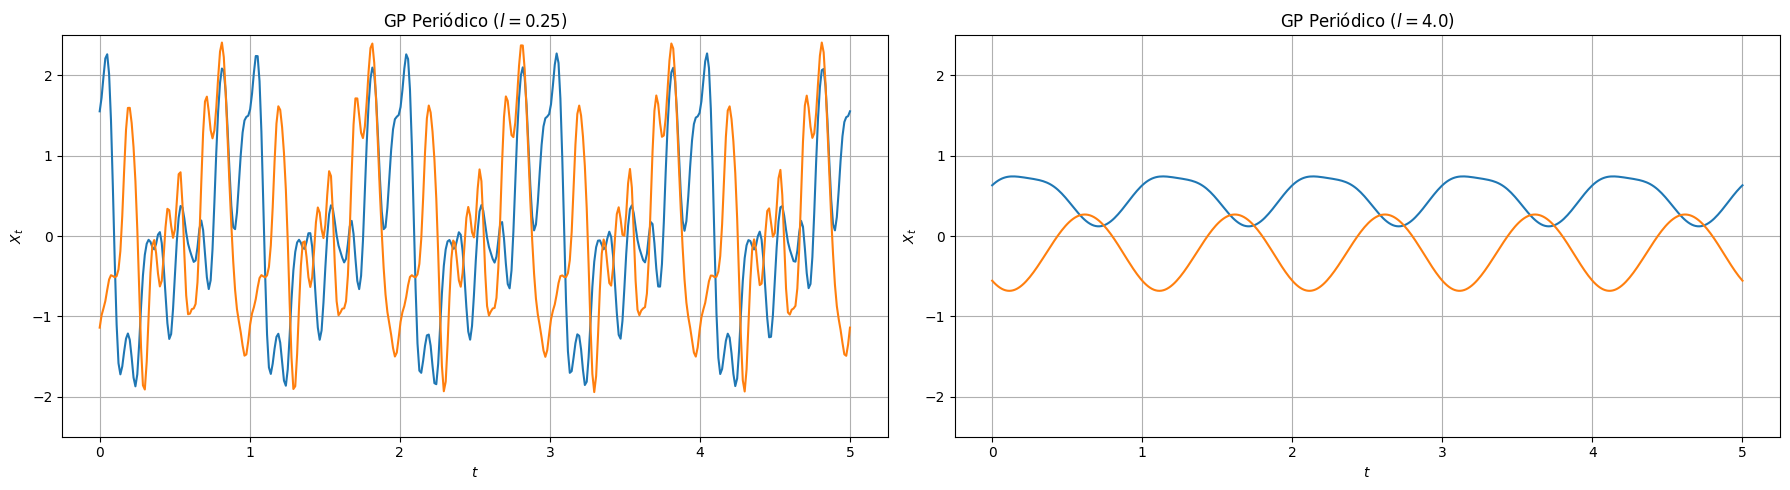

In [8]:
t = np.linspace(0, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].autoscale(enable=True, axis='both')

# Primer subplot (lenghtscale=0.25)
axes[0].plot(t, simular_GP_periodic(t, 1, 0.25, 1, 2).T)
axes[0].set_title('GP Periódico $(l=0.25)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-2.5, 2.5)
axes[0].grid()

# Segundo subplot (lenghtscale=4)
axes[1].plot(t, simular_GP_periodic(t, 1, 4, 1, 2).T)
axes[1].set_title('GP Periódico $(l=4.0$)')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-2.5, 2.5)
axes[1].grid()


plt.tight_layout()
plt.show()

## Diapositiva 74

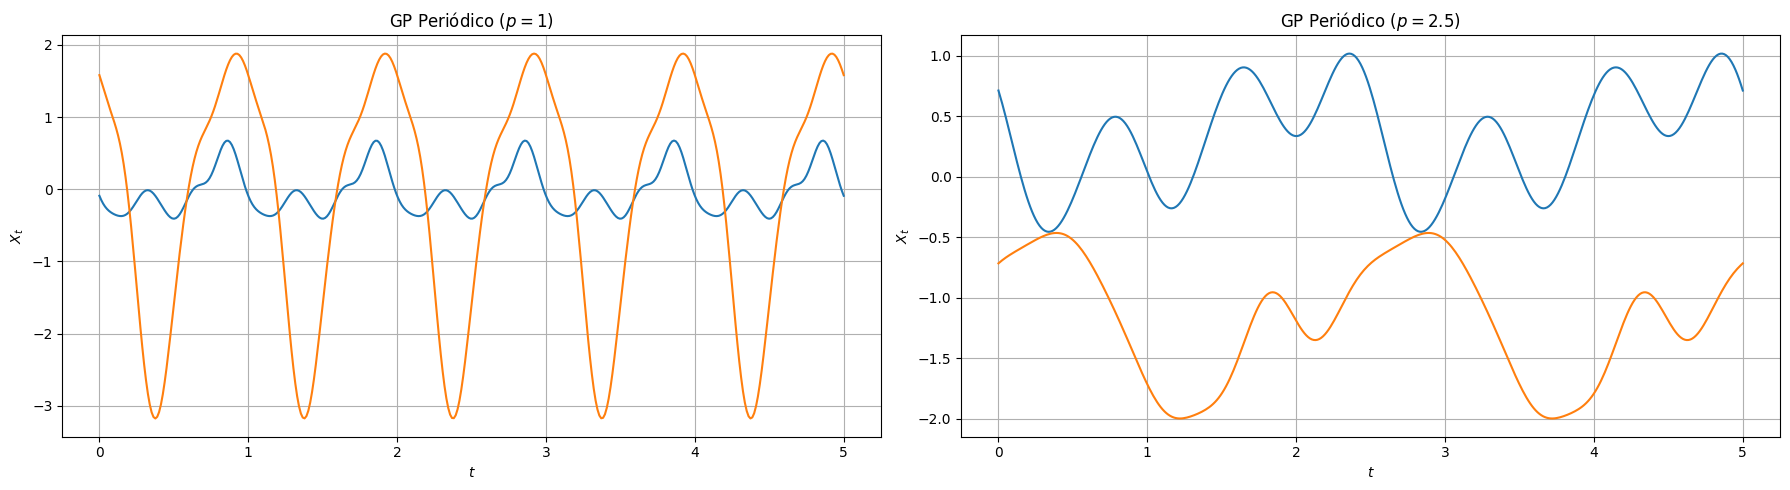

In [9]:
t = np.linspace(0, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].autoscale(enable=True, axis='both')

# Primer subplot (p=1)
axes[0].plot(t, simular_GP_periodic(t, 1, 1, 1, 2).T)
axes[0].set_title('GP Periódico $(p=1)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].grid()

# Segundo subplot (p=2.5)
axes[1].plot(t, simular_GP_periodic(t, 1, 1, 2.5, 2).T)
axes[1].set_title('GP Periódico $(p=2.5)$')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].grid()


plt.tight_layout()
plt.show()

## Diapositiva 76

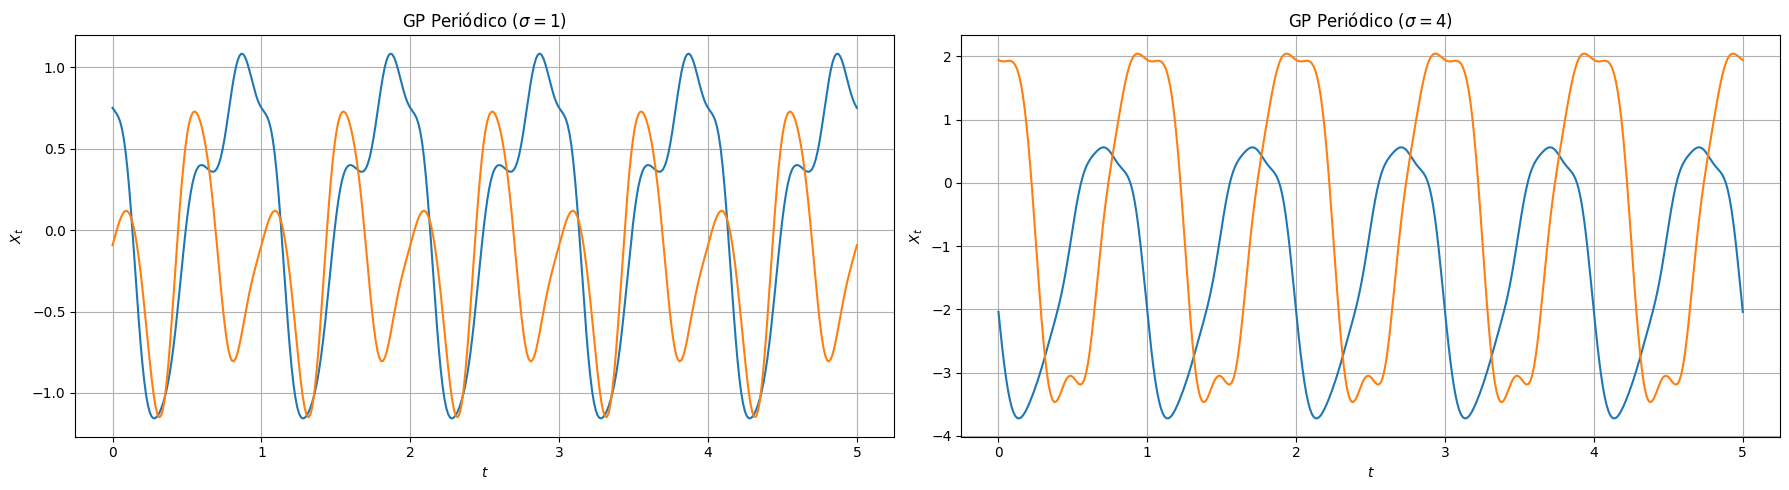

In [10]:
t = np.linspace(0, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].autoscale(enable=True, axis='both')

# Primer subplot (sigma_sq=1)
axes[0].plot(t, simular_GP_periodic(t, 1, 1, 1, 2).T)
axes[0].set_title('GP Periódico $(\\sigma=1)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].grid()

# Segundo subplot (sigma_sq=4)
axes[1].plot(t, simular_GP_periodic(t, 4, 1, 1, 2).T)
axes[1].set_title('GP Periódico $(\\sigma=4)$')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].grid()


plt.tight_layout()
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [20]:
def simular_GP_DPKpoly(t, m, num_samples):
  #Calcular el vector de medias.
  vector_medias = np.zeros_like(t)

  #Calcular la matriz de covarianzas.
  columna_potencias = np.arange(0, m+1).reshape(m+1, 1)
  matriz_funcs = t ** columna_potencias
  matriz_covs = np.dot(matriz_funcs.T, matriz_funcs)

  #"jitter" para que sea semidefinida positiva
  matriz_covs += 1e-9 * np.eye(matriz_covs.shape[0])

  # Obtener las muestras/simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples

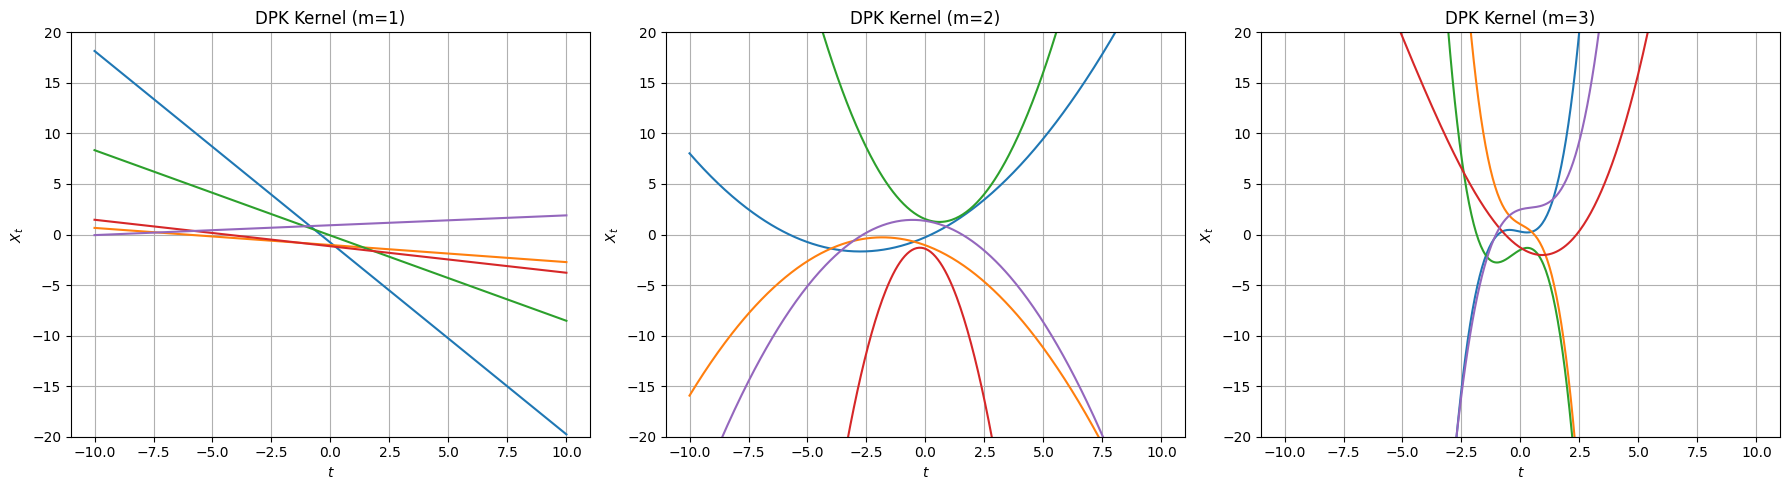

In [22]:
t = np.linspace(-10, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Primer subplot (m=1)
axes[0].plot(t, simular_GP_DPKpoly(t, 1, 5).T)
axes[0].set_title('DPK Kernel (m=1)')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-20, 20)
axes[0].grid()

# Segundo subplot (m=2)
axes[1].plot(t, simular_GP_DPKpoly(t, 2, 5).T)
axes[1].set_title('DPK Kernel (m=2)')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-20, 20)
axes[1].grid()

# Tercer subplot (m=3)
axes[2].plot(t, simular_GP_DPKpoly(t, 3, 5).T)
axes[2].set_title('DPK Kernel (m=3)')
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$X_t$')
axes[2].set_ylim(-20, 20)
axes[2].grid()

plt.tight_layout()
plt.show()

## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [13]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [14]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación definimos una clase para la función de medias constantemente igual a cero:

In [15]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [16]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [17]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [18]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

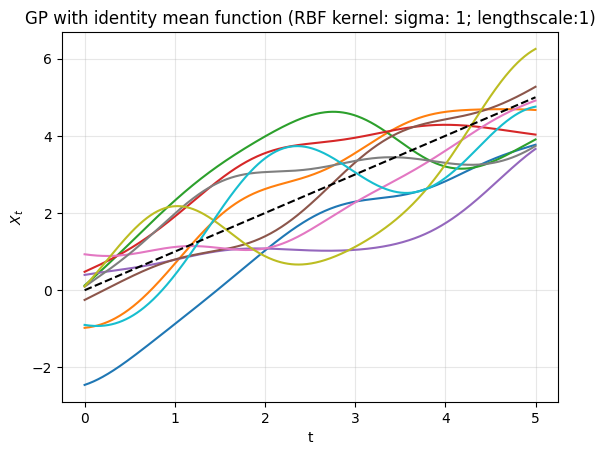

In [19]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()
